In [ ]:
from kevlib import common_import_script
%run $common_import_script
from astropy.coordinates import SkyCoord
from astroscrappy import detect_cosmics
from astropy.convolution import Gaussian2DKernel, interpolate_replace_nans
import lmfit
from astropy.io import fits
from kevlib.utils.plot import plot_images
from glob import glob
import kevlib.image as kli
from kevlib.utils import fix_byte_order
import urllib.parse
from astropy.io import ascii as astro_ascii
from scipy.ndimage import binary_dilation, binary_erosion
import shapely
from shapely.geometry import Polygon, Point

def is_point_inside_bounding_area(bounding_points, point_to_check):
    polygon = Polygon(bounding_points)
    
    point = Point(point_to_check)
    
    return polygon.contains(point)

/media/rd1/kwillis/kevlib_dev/src/kevlib/common_imports.py:6: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange  # 231010


---------------------------------------------------------------------------------------
|                        Last run date: 2025-07-06 06:54 PM E                         |
---------------------------------------------------------------------------------------
| Python | Jupyterlab | Numpy  | Scipy  | Astropy | Matplotlib | Tensorflow | Pytorch |
---------------------------------------------------------------------------------------
| 3.11.4 |   4.4.3    | 1.24.3 | 1.11.1 |  5.3.1  |   3.8.3    |   2.13.1   |  2.0.1  |
---------------------------------------------------------------------------------------


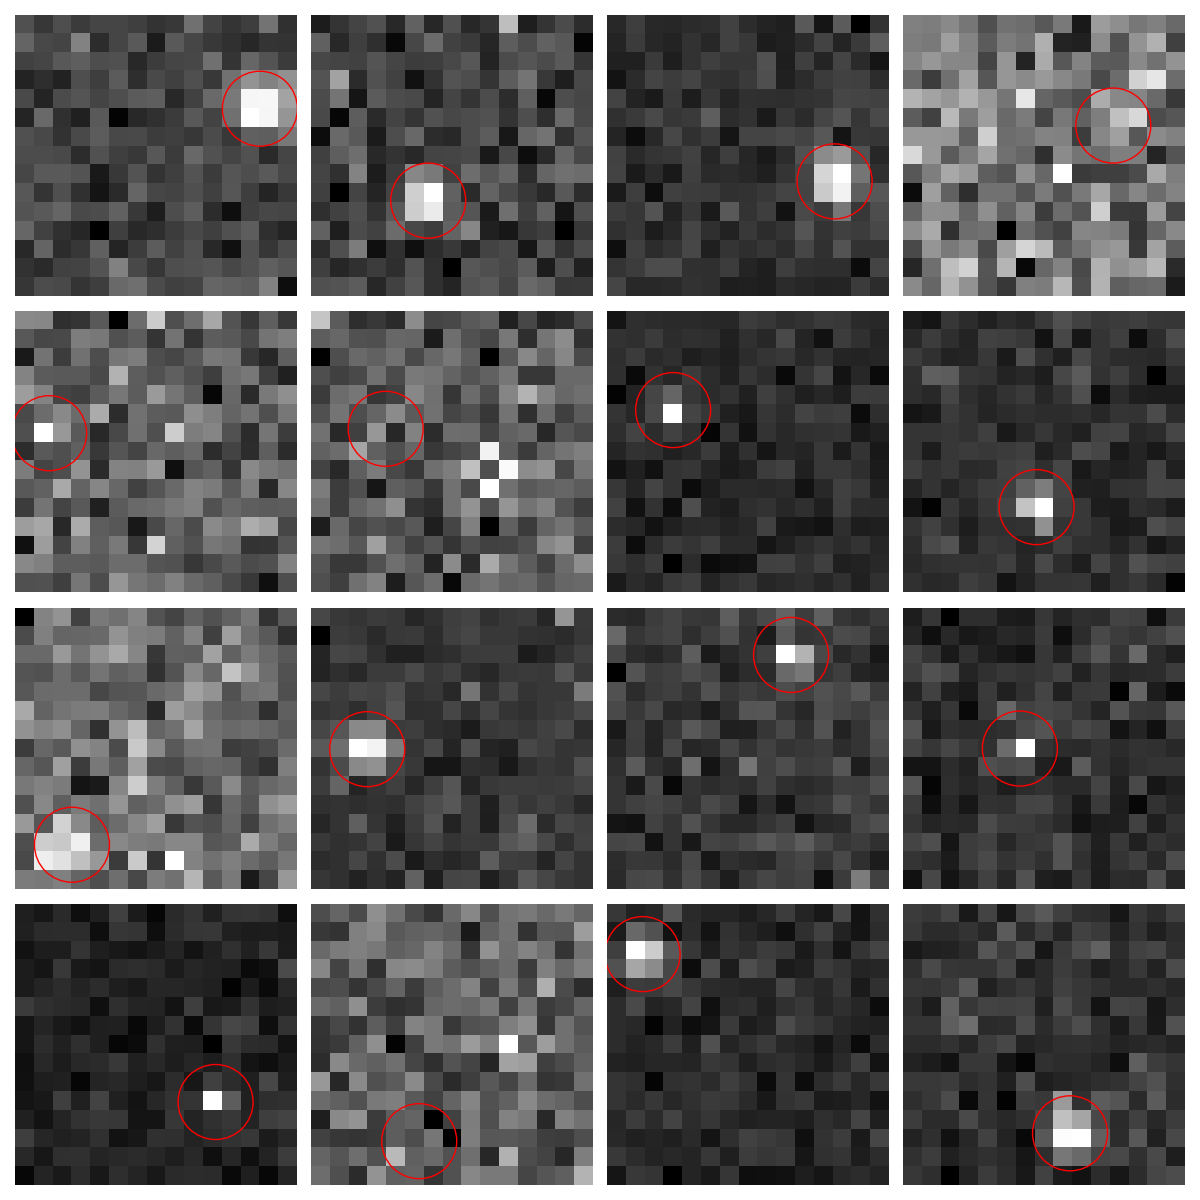

In [98]:
plot_images_with_circles(np.array(implanted_true), centers, grid_dim=(4,4), circle_radius=2)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def plot_images_with_circles(images, coordinates, grid_dim=(4,4), circle_radius=2):

    num_images = images.shape[0]
    if grid_dim is None:
        grid_size = int(np.ceil(np.sqrt(num_images)))
        nrows, ncols = grid_size, grid_size
    else:
        nrows, ncols = grid_dim

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axes = axes.ravel()

    for idx, ax in enumerate(axes):
        if idx < num_images:
            img = images[idx]
            coord = coordinates[idx]
            ax.imshow(img, cmap='gray')
            circle = Circle((coord[0], coord[1]), circle_radius, color='red', fill=False)
            ax.add_patch(circle)
            ax.axis('off')
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()
    

In [2]:
# implanted_true = np.array(implanted_true)
# centers = np.array(centers)

In [2]:
from kevlib import common_import_script
%run $common_import_script
from astropy.coordinates import SkyCoord
from astroscrappy import detect_cosmics
from astropy.convolution import Gaussian2DKernel, interpolate_replace_nans
import lmfit
from astropy.io import fits
from kevlib.utils.plot import plot_images


---------------------------------------------------------------------------------------
|                        Last run date: 2025-07-06 06:54 PM E                         |
---------------------------------------------------------------------------------------
| Python | Jupyterlab | Numpy  | Scipy  | Astropy | Matplotlib | Tensorflow | Pytorch |
---------------------------------------------------------------------------------------
| 3.11.4 |   4.4.3    | 1.24.3 | 1.11.1 |  5.3.1  |   3.8.3    |   2.13.1   |  2.0.1  |
---------------------------------------------------------------------------------------


In [2]:
import numpy as np

# 1. Fit the dim W2 images

In [3]:
dim_w2_ims = np.load("./15px_W2_masks_real_asteroids_centered.npy")

In [4]:
len(dim_w2_ims)

100

In [4]:
dims_full = [im for im in dim_w2_ims if np.max(im) != 0]

In [180]:
# plot_images(dims_full[90:100],fig_height=2)

In [18]:
# np.std(dims_full[4])

In [5]:
remove_ims = [12,14,47,60,63,70,86,97,98,99]
clear_reals = [dims_full[i] for i in range(len(dims_full)) if i not in remove_ims]

dims_full = clear_reals

In [6]:
# Define the model
def gaussian2d(x, y, amplitude, centerx, centery, sigmax, sigmay, theta):
    
    a = (np.cos(theta)**2)/(2*sigmax**2) + (np.sin(theta)**2)/(2*sigmay**2)
    b = -(np.sin(2*theta))/(4*sigmax**2) + (np.sin(2*theta))/(4*sigmay**2)
    c = (np.sin(theta)**2)/(2*sigmax**2) + (np.cos(theta)**2)/(2*sigmay**2)
    
    gauss = amplitude * np.exp( - (a*((x-centerx)**2) + 2*b*(x-centerx)*(y-centery) + c*((y-centery)**2)))
    
    return gauss
import math

def reduced_chi_squared(observed, expected, sigma, num_parameters):

    N = np.size(observed)
    nu = N - num_parameters
    chi2 = np.sum((observed - expected)**2 / sigma**2)
    chi2_red = chi2 / nu
    return chi2_red


from astropy.stats import sigma_clipped_stats

# im_uncert = np.full_like(im_crop, sigma_clipped_stats(im_crop)[2]) # Uncertaintiy per pixel estimation

# chi2_red = reduced_chi_squared(observed=im_crop, expected=fitted_model, sigma=im_uncert, num_parameters=6)

# chi2_red

imgarray = []
fitted_imgarray = []
residuals = []
ct = 0
file = []
for im in dims_full:
     
        with warnings.catch_warnings():
            
            warnings.filterwarnings("ignore")
            
            im = interpolate_replace_nans(im, Gaussian2DKernel(x_stddev=1))
            
            im = detect_cosmics(im)[1]

            im_crop = im
                
            model = lmfit.Model(gaussian2d, independent_vars=('x', 'y'))
            
            params = model.make_params()
    
            amp_est = np.nanmax(im)
            print("amp: ", amp_est)
                
            # y_est, x_est = np.unravel_index(np.nanargmax(im_crop), im_crop.shape)
            y_est, x_est = 8,8

            # -----------------------------------------------------
            
            params['amplitude'].set(value=amp_est, min=amp_est*0.5, max=amp_est*1.5)
            params['centerx'].set(value=x_est, min=x_est-2, max=x_est+2)
            params['centery'].set(value=y_est, min=y_est-2, max=y_est+2)
            params['sigmax'].set(value=1.0, min=0.1, max=10.0)
            params['sigmay'].set(value=1.0, min=0.1, max=10.0)
            params['theta'].set(value=0.0, min=None, max=None)
    
            #----------------------------------------------------
            
            x = np.arange(im_crop.shape[1])
            y = np.arange(im_crop.shape[0])
            
            X, Y = np.meshgrid(x, y)
            
            result = model.fit(params=params, data=im_crop, x=8, y=8, method='powell')
    
            #-------------------------------------------
            
            fitted_model = result.best_fit
            
            fit_residual = im_crop - fitted_model
            
            fitted_imgarray.append(fitted_model)
            residuals.append(fit_residual)
    
            #--------------------------------------------
            
            param_dict = result.params.valuesdict()
            im_uncert = np.full_like(im_crop, sigma_clipped_stats(im_crop)[2]) # Uncertainty per pixel estimation
            chi2_red = reduced_chi_squared(observed=im_crop, expected=fitted_model, sigma=im_uncert, num_parameters=6)
         
            p_list = list(param_dict.values())
            p_list.append(chi2_red)
            
            file.append(p_list)
            ct+=1
            print("# of fitted gaussians:", ct)
            plt.close()

s_amp = []
s_centerx= []
s_centery= []
s_sigmax= []
s_sigmay= []
s_theta= []
s_chi= []

# file = filterfile

for m in range(len(file)):
    # print(m)
    s_amp.append(file[m][0])
    s_centerx.append(file[m][1])
    s_centery.append(file[m][2])
    s_sigmax.append(file[m][3])
    s_sigmay.append(file[m][4])
    s_theta.append(file[m][5])
    s_chi.append(file[m][6])

amp:  1.0524716
# of fitted gaussians: 1
amp:  1.8067058
# of fitted gaussians: 2
amp:  2.2842684
# of fitted gaussians: 3
amp:  1.4982893
# of fitted gaussians: 4
amp:  1.1506994
# of fitted gaussians: 5
amp:  0.8889752
# of fitted gaussians: 6
amp:  2.3010373
# of fitted gaussians: 7
amp:  1.1491702
# of fitted gaussians: 8
amp:  1.0230567
# of fitted gaussians: 9
amp:  0.73706305
# of fitted gaussians: 10
amp:  0.7036948
# of fitted gaussians: 11
amp:  1.0914731
# of fitted gaussians: 12
amp:  0.6013526
# of fitted gaussians: 13
amp:  1.4935038
# of fitted gaussians: 14
amp:  1.7808882
# of fitted gaussians: 15
amp:  1.7715603
# of fitted gaussians: 16
amp:  1.24969
# of fitted gaussians: 17
amp:  1.1846046
# of fitted gaussians: 18
amp:  1.095175
# of fitted gaussians: 19
amp:  1.2885484
# of fitted gaussians: 20
amp:  1.4741119
# of fitted gaussians: 21
amp:  1.61735
# of fitted gaussians: 22
amp:  2.9065058
# of fitted gaussians: 23
amp:  2.022847
# of fitted gaussians: 24
amp:  

In [ ]:
plt.imshow(image_array_grayscale)

In [427]:
s_amp = np.array(s_amp)
f_amp = s_amp

s_sigmax = np.array(s_sigmax)
f_sigmax = s_sigmax
# f_sigmax = s_sigmax

# s_sigmay = np.array(s_sigmay)
# f_sigmay = s_sigmay]s_sigmay < 2]
# f_sigmay = f_sigmay[f_sigmay > 0.6]

In [330]:
# s_sigmax

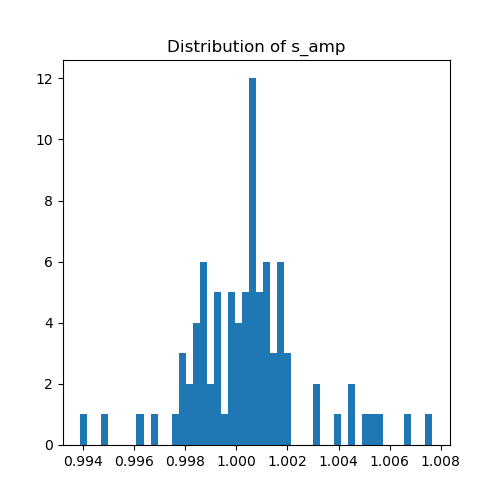

In [458]:
plt.figure(figsize=(5,5))
plt.hist(s_sigmax[s_sigmax > 0.8], bins=50)
plt.title("Distribution of s_amp")
plt.show()

In [10]:
# f_sigmax >0.8

In [11]:
# f_sigmax

# 2. Use fits to generate new images

In [211]:
# plt.figure()
# plt.plot(f_amp, f_sigmax, ".k")

In [428]:

from scipy.stats import norm, uniform

amplitude_fit_params = uniform.fit(f_amp)

sigmax_fit_params = uniform.fit(f_sigmax)

In [7]:
plot_images([dims_full[x], sim], fig_height=2, norm_mode="normal")

In [53]:
x = 80
sim, _ = generate_gaussian_image(file[x][0], file[x][1], file[x][2], file[x][3], file[x][4])

In [7]:
def generate_gaussian_image(amplitude, centerx, centery, sigmax, sigmay, width=15, height=15):
    x, y = np.meshgrid(np.arange(width), np.arange(height))
    
    x_centered = x - centerx
    y_centered = y - centery

    gaussian_image = amplitude * np.exp(
        -((x_centered) ** 2 / (2 * sigmax ** 2) + (y_centered) ** 2 / (2 * sigmay ** 2))
    )

    params_used = [amplitude, centerx, centery, sigmax, sigmay]
    return gaussian_image, params_used

In [431]:
sigmax_fit_params[1] > sigmax_fit_params[0]

True

In [533]:
num_samples=10
clean_bkgs = np.load("../2025Summer/TrainingData/TrueSet/Final_TrueBkgs_470k_ReadyforSynthImplant.npy")

# num_samples=len(clean_bkgs)


def generate_gaussian_image(amplitude, centerx, centery, sigmax, sigmay, width=15, height=15):
    x, y = np.meshgrid(np.arange(width), np.arange(height))
    
    x_centered = x - centerx
    y_centered = y - centery

    gaussian_image = amplitude * np.exp(
        -((x_centered) ** 2 / (2 * sigmax ** 2) + (y_centered) ** 2 / (2 * sigmay ** 2))
    )

    params_used = [amplitude, centerx, centery, sigmax, sigmay]
    return gaussian_image, params_used
#----------------------------------------------------------------------------------------------------------


from photutils.aperture import CircularAnnulus
import numpy as np



def calculate_snr_normalized(image_data, position, aperture_radius, annulus_radii, sigma=0.2):
    aperture = CircularAperture(position, r=aperture_radius)
    annulus = CircularAnnulus(position, r_in=annulus_radii[0], r_out=annulus_radii[1])
    aperture_phot = aperture_photometry(image_data, aperture)
    signal = aperture_phot['aperture_sum'][0]
    
    annulus_phot = aperture_photometry(image_data, annulus)
    bkg_mean = annulus_phot['aperture_sum'][0] / annulus.area
    bkg_total = bkg_mean * aperture.area
    net_signal = signal - bkg_total
    
    N_pixels = aperture.area
    total_noise = sigma * np.sqrt(N_pixels)
    
    snr = net_signal / total_noise if total_noise != 0 else 0
    
    return snr, aperture



gauss_params = []
centers = []
implanted_true = []
SNRs = []
sim_images = []


for i in tqdm(range(len(clean_bkgs))):
    cx = np.random.uniform(1,14)
    cy = np.random.uniform(1,14)
    # cx, cy = 8,8

    y = np.random.uniform(-0.01,0.01)

    curr_snr = 0;

    loop = 0
    
    while curr_snr <  3:

        
        sampled_amp = np.random.uniform(low=amplitude_fit_params[0], high=amplitude_fit_params[1]-0.5)

        sampled_sigmax = np.random.uniform(low=0.99, high=1.4)

        img, p = generate_gaussian_image(sampled_amp, cx, cy, sampled_sigmax, sampled_sigmax + y)
        
        add = clean_bkgs[i] + img
    
        curr_snr, aperture = calculate_snr_normalized(add, position=(cx, cy), aperture_radius=1.5, annulus_radii=[3, 4])
        loop+=1 

        if loop == 4:
            break
        
    centers.append([cx, cy])

    sim_images.append(img)
    implanted_true.append(add)
    gauss_params.append(p)

    SNRs.append(curr_snr)
    

  0%|          | 0/452732 [00:00<?, ?it/s]

In [534]:
SNRs = np.array(SNRs)

In [8]:
plt.figure(figsize=(12,4))
plt.hist(SNRs[(SNRs > 3) & (SNRs < 20)], bins=40)
plt.xlabel("SNR")
plt.title("SNR of (Unfiltered) Synthetic Images")
plt.ylabel("# of Images")
plt.show()

In [541]:
len(SNRs[(SNRs > 3) & (SNRs < 20)])

447748

In [450]:
# plt.figure(figsize=(5,5))
# plt.hist(sampled_amp, bins=20)

# # plt.title("Distribution of Amplitude parameter: pre-SNR filtering")
# plt.show()

# 3. Implant fits into bkg images

In [183]:
def randomSky(numImages):
    training_samples = []
    # rDay = np.random.randint(56660,59000)
    rDay = 57095

    print(rDay)
    
    mjd_start = rDay
    mjd_end = rDay + 1

    query = f"""https://irsa.ipac.caltech.edu/cgi-bin/Gator/nph-query?catalog=neowiser_p1bm_frm&spatial=None&outfmt=1&constraints=
    ((mjd_obs>{mjd_start} and mjd_obs<{mjd_end})) and
    band=1 and 
    (qa_status='Reviewed' or qa_status='Final') and
    qual_frame > 5 and
    moon_sep >= 0 and
    saa_sep > 0
    """
    url = urllib.parse.quote(query, safe=':/?=&()>')
    download_tbl = astro_ascii.read(url)
    download_tbl = download_tbl.to_pandas()

    print("length of table ", len(download_tbl))

    
    for m in range(numImages):
        
        row = download_tbl.iloc[m]
        id = [row["frame_num"], row["scan_id"], row["scangrp"], row["mjd_obs"]]
        print(row["ra1"], row["dec1"])
        training_samples.append(id)
        
    return training_samples

rands = randomSky(30)

def get_single_file_url(scan_id, scangrp, frame_num):

    irsa_url = "%s/%s/%03d/" % (scangrp, scan_id, frame_num)

    filename = f"{scan_id:s}{frame_num:03d}-w2-int-1b.fits"

    irsa_url = f'https://irsa.ipac.caltech.edu/ibe/data/wise/neowiser/p1bm_frm/{irsa_url}/{filename}'
    
    return irsa_url

#----------------------------------------------------------------------------------------------------------------------------

def URL_list(megalist):
    urllist = []
    for i in megalist:
        url = get_single_file_url(i[1], i[2], int(i[0]))
        urllist.append(url)
    return urllist

urllist = URL_list(rands)

def mask_cut(list):
    grids = []
    all_corners = []
    coadds = []
    bitmasks = []
    
    for i in tqdm(range(len(list))): 
        
        print("On frame " , i)
        m, coadd, single = maskImage(list[i])
        
        # hdul = fits.open(list[i])        
        # header = hdul[0].header # Extract the image header containing WCS info
        # wcs = get_wcs(header)
        
        print("mask done")
        
        squares, corners = grid_image(m, square_size=15)

         # Bitmasks
        bitmask_url = list[i][:87] + "w1-msk-1b.fits.gz"
        bmask = fits.open(bitmask_url)
        bmask = bmask[0].data
        b_grid, _ = grid_image(bmask, 15)
    
        # Coadd
        c_grid, _ = grid_image(coadd, 15)

        #Single
        s_im, _ = grid_image(single, 15)
        
        print("gridding done")
        
        grids.append(squares)
        coadds.append(c_grid)
        bitmasks.append(b_grid)
        
        all_corners.append(corners)
    return grids, coadds, bitmasks, s_im, all_corners

#-----------------------------

def maskImage(path, showImage=False):
    single_path = path
    im_single = fix_byte_order(fits.getdata(single_path))

    s_bkg, s_rms = kli.background.measure_bkg_and_rms(im_single, meas_window_size=[10]*2, outlier_sigma=3, blur_sigma=20, blur_kernel_size=31, device='cpu')
    im_single_br = im_single - s_bkg
    
    im_single_c = kli.nan_infill(im_single_br, s_rms)
    
    im_coadd = kli.wise.make_wise_coadd(single_path)
    
    c_bkg, c_rms = kli.background.measure_bkg_and_rms(im_coadd, meas_window_size=[10]*2, outlier_sigma=3, blur_sigma=20, blur_kernel_size=31, device='cpu')
    im_coadd_br = im_coadd - c_bkg 
    
    c_obj_map = im_coadd_br > 0.05
    
    c_obj_map = binary_dilation(binary_erosion(c_obj_map, iterations=1), iterations=2)

    
    im_single_masked = im_single_c.copy()
    im_single_masked[c_obj_map] = np.nan
    
    
    s_bkg, s_rms = kli.background.measure_bkg_and_rms(
        im_single_masked, meas_window_size=[10]*2, outlier_sigma=3, 
        blur_sigma=20, blur_kernel_size=31, device='cpu',
    )
    s_b = im_single_masked - s_bkg
    s_i = kli.nan_infill(s_b, s_rms)

    #--------------------------------------------------------------------------------------------------------------------------------------------------------

    constant_scaler = 5

    s_norm = s_i.copy()
    
    s_norm /= (s_rms * constant_scaler)
    np.min(s_norm), np.max(s_norm), sigma_clipped_stats(s_norm.flatten())[2]
    
    np.percentile(s_norm.flatten(), [1, 5, 10, 90, 95, 99])
    
    np.clip(s_norm, -1, 1, out=s_norm)
    
    #--------------------------------------------------------------------------------------------------------------------------------------------------------

    if showImage:
        axs = plot_images(
            ims=[im_single_c, s_i, im_coadd], 
            title=None, norm_same=False, fig_height=4, 
            norm_kwargs=dict(min_cut=-1, max_cut=1000), 
            imshow_kwargs=dict(cmap='viridis')
        )
        [ax.set_title(t) for ax, t in zip(axs, ['Single', 'Masked Single', 'Coadd'])];

    return s_i, im_coadd, im_single


import numpy as np
from PIL import Image

def grid_image(image_array, square_size):
    corners = []
    image = Image.fromarray(image_array)

    # Get the size of the original image
    width, height = image.size

    # Calculate the number of squares in both dimensions
    num_squares_x = width // square_size
    num_squares_y = height // square_size

    squares = []
    # Loop through the image and crop it into smaller squares
    for i in range(num_squares_x):
        for j in range(num_squares_y):
            left = i * square_size
            upper = j * square_size
            right = (i + 1) * square_size
            lower = (j + 1) * square_size

            square = image.crop((left, upper, right, lower))
            # if left == 0:
            #     print(left, upper, right, lower)
            
            # Convert the square to a NumPy array and append to the list
            square_array = np.array(square)
            squares.append(square_array)

            # midpt = midpoint(left, upper, right, lower)
            corners.append([left,upper])
            # print("corner: ", left, upper)
    return squares, corners

57095
length of table  5798
269.499170201682 85.528762557353
269.736625139555 84.832282143462
269.915389412654 84.136129836788
270.051810293271 83.441435296296
270.160856205166 82.745827005191
270.251780870066 82.050129070809
270.330798323576 81.353988090107
270.399443005961 80.65773019228
270.457075066205 79.96206099593
270.505975769699 79.266541387492
270.549963009878 78.570730821042
270.590278754409 77.874585812385
270.626801438621 77.178191235308
270.662327681691 76.481457879826
270.695652432057 75.784736300485
270.724780396765 75.088159180314
270.750102061952 74.391540632187
270.773703427917 73.694726164778
270.796003992467 72.998680355738
270.816283933832 72.302984337412
270.834817290966 71.60689705488
270.852067316436 70.910923449114
270.869065451224 70.214922175045
270.884929814692 69.518795187528
270.926034270532 67.427857876696
270.938473694046 66.731605869794
270.950835888391 66.035303055434
270.963511027956 65.339286879853
270.975670571349 64.643575050266
270.986343944759 6

In [10]:
import numpy as np

def find_patterns(image):
    target_value = 268435456

    height=15
    width=15
    mask_image = np.zeros((height, width), dtype=int)

    for y in range(height - 1):
        for x in range(width - 1):
            if (image[y, x] == target_value and
                image[y, x + 1] == target_value and
                image[y + 1, x] == target_value and
                image[y + 1, x + 1] == target_value):
                
                mask_image[y, x] = 1
                mask_image[y, x + 1] = 1
                mask_image[y + 1, x] = 1
                mask_image[y + 1, x + 1] = 1

            if (image[y, x] == target_value and
                image[y + 1, x + 1] == target_value):
                mask_image[y, x] = 1
                mask_image[y + 1, x + 1] = 1

            if (image[y, x + 1] == target_value and
                image[y + 1, x] == target_value):
                mask_image[y, x + 1] = 1
                mask_image[y + 1, x] = 1

            if image[y, x] == target_value and image[y + 1, x] == target_value:
                mask_image[y, x] = 1
                mask_image[y + 1, x] = 1

            if image[y, x] == target_value and image[y, x + 1] == target_value:
                mask_image[y, x] = 1
                mask_image[y, x + 1] = 1

    for y in range(height - 1):
        if image[y, width - 1] == target_value and image[y + 1, width - 1] == target_value:
            mask_image[y, width - 1] = 1
            mask_image[y + 1, width - 1] = 1

    for x in range(width - 1):
        if image[height - 1, x] == target_value and image[height - 1, x + 1] == target_value:
            mask_image[height - 1, x] = 1
            mask_image[height - 1, x + 1] = 1

    return mask_image


def remove_artifacts(mask, img):
    
    original_img = np.copy(img)
    
    bm = find_patterns(mask)
    c_obj_map = binary_dilation(bm, iterations=4)
    
    img[c_obj_map] = np.nan
    non_nan_pixels = img[~np.isnan(img)]
    background_noise = np.std(non_nan_pixels)
    
    nan_mask = np.isnan(img)
    
    img[nan_mask] = np.random.normal(0, background_noise, size=nan_mask.sum())
    
    if (original_img==img).all():
        corrected = False;
    else:
        corrected= True
    return img, corrected

In [ ]:
grids, coadds, bitmasks, singles, topcorners = mask_cut(urllist)

In [204]:
bitmasks_g = [i for a in bitmasks for i in a]
grids_g = [i for a in grids for i in a]

In [9]:

clean_bkgs = []
artifacts = []

for i in tqdm(range(len(bitmasks_g))):
    im, c = remove_artifacts(bitmasks_g[i], grids_g[i])
    clean_bkgs.append(im)
    artifacts.append(c)

In [206]:
np.save("./TrainingData/Oct27_DimSynthAsteroidBackgroundImages_134k_update", clean_bkgs)

In [182]:
# def mask_cut(list):
#     grids = []

#     for i in range(len(list)): 
#         print("On image " , i)
#         m = maskImage(list[i])
#         print("mask done")
#         squares = grid_image(m, square_size=15)
#         print("gridding done")
#         grids.append(squares)
#     return grids

# grids = mask_cut(urllist)
# grids = [i for m in grids for i in m if np.shape(i)==(15,15)] # ONLY RUN ONCE!

In [10]:
# grids = np.load("15sizeGrids_maskedbackgrounds.npy")

In [145]:
clean_bkgs = np.load("./TrainingData/Oct27_DimSynthAsteroidBackgroundImages_134k_update.npy")

# Implanet Synthetic Images

In [27]:
# clean_bkgs = np.load("./TrainingData/March19_True_Training_Bkgs_134k-Copy1.npy")
clean_bkgs = np.load("../2025Summer/TrainingData/TrueSet/Final_TrueBkgs_470k_ReadyforSynthImplant.npy")

implanted_true = []
ct = 0

for i in range(len(simImages)):

    add = clean_bkgs[i] + simImages[i]
    implanted_true.append(add)
    
raw_implanted_true = np.array(implanted_true)
raw_centers = np.array(centers)

In [18]:
len(raw_implanted_true)

1000

[6.839458474254826, 5.713304949275133]

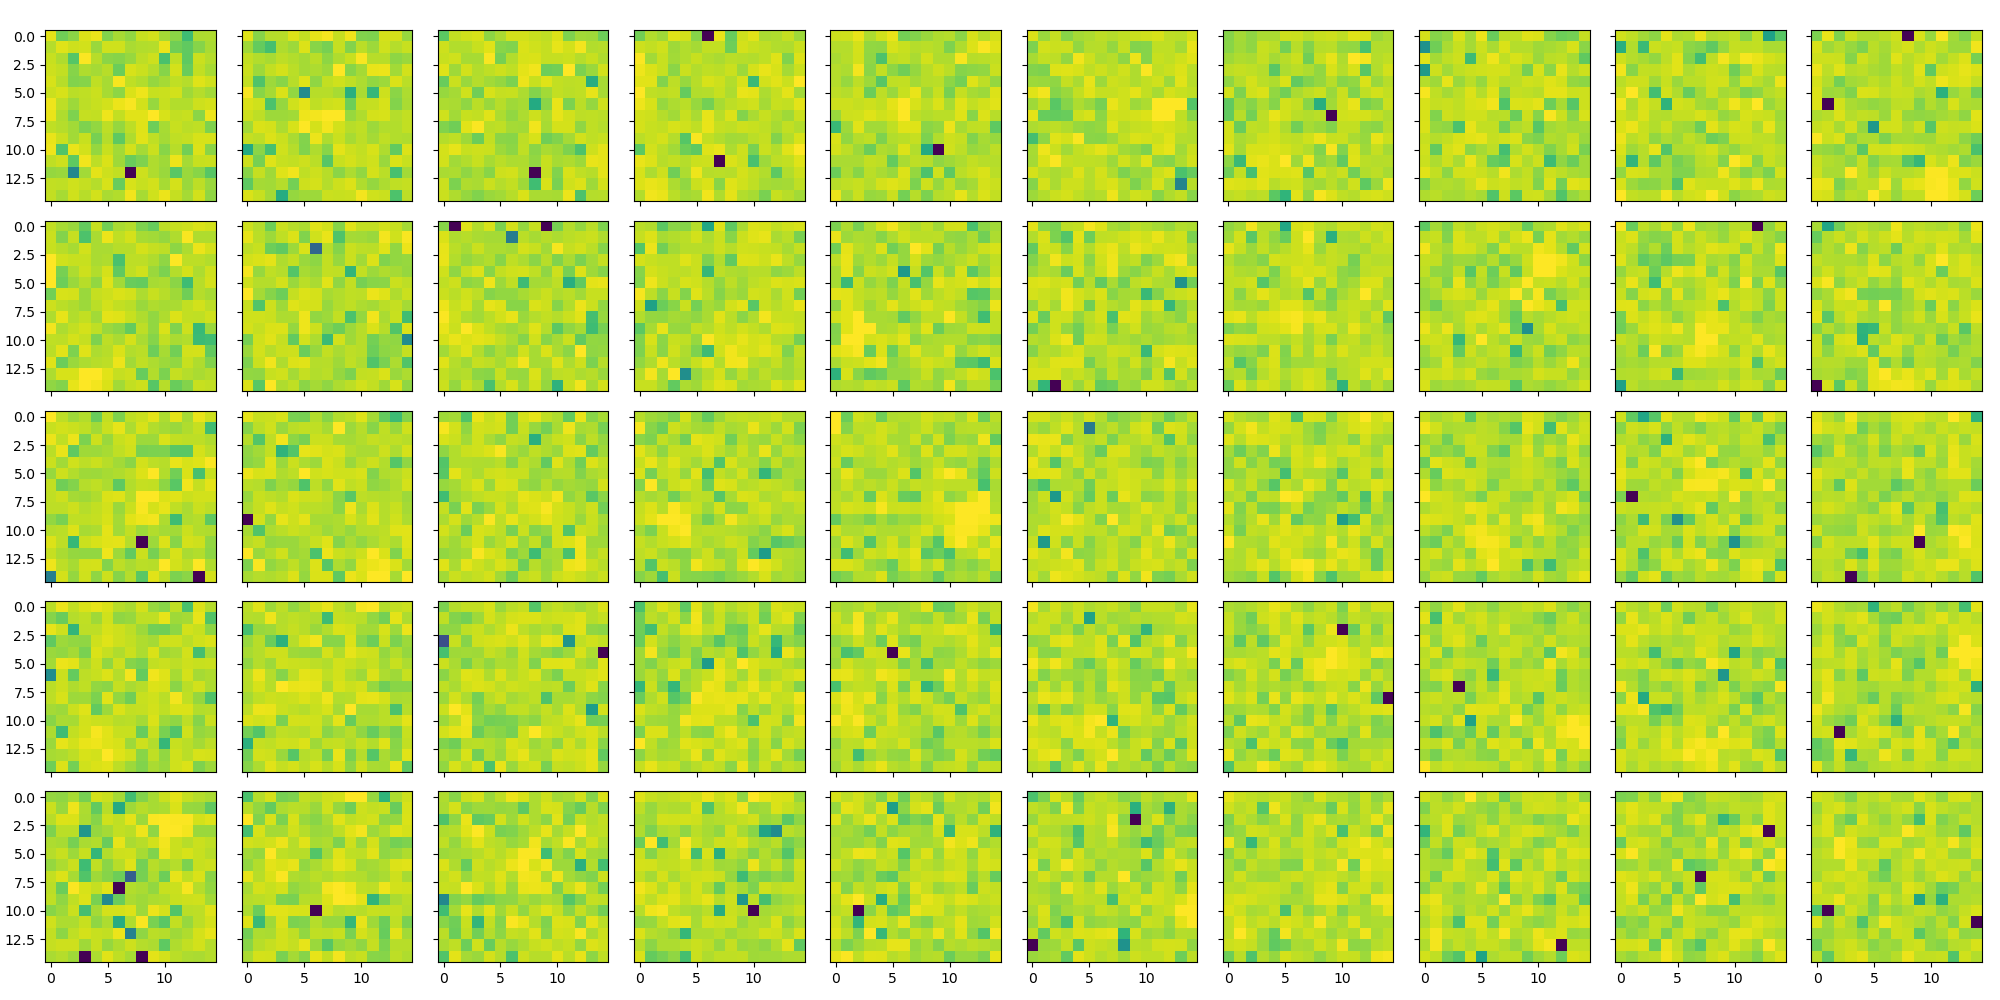

In [28]:
x = 30


plot_images(implanted_true[x:x+50], n_rows = 5, fig_height=2)

centers[x]

In [51]:
plt.close()

In [113]:
len(fil), len(fil_centers)

(41280, 41280)

In [26]:
# np.save("feb16_centers_SNR3to8_nobkgRemoved", fil_centers)
# np.save("feb16_synthetic_ims_SNR3to8_nobkgRemoved", fil)

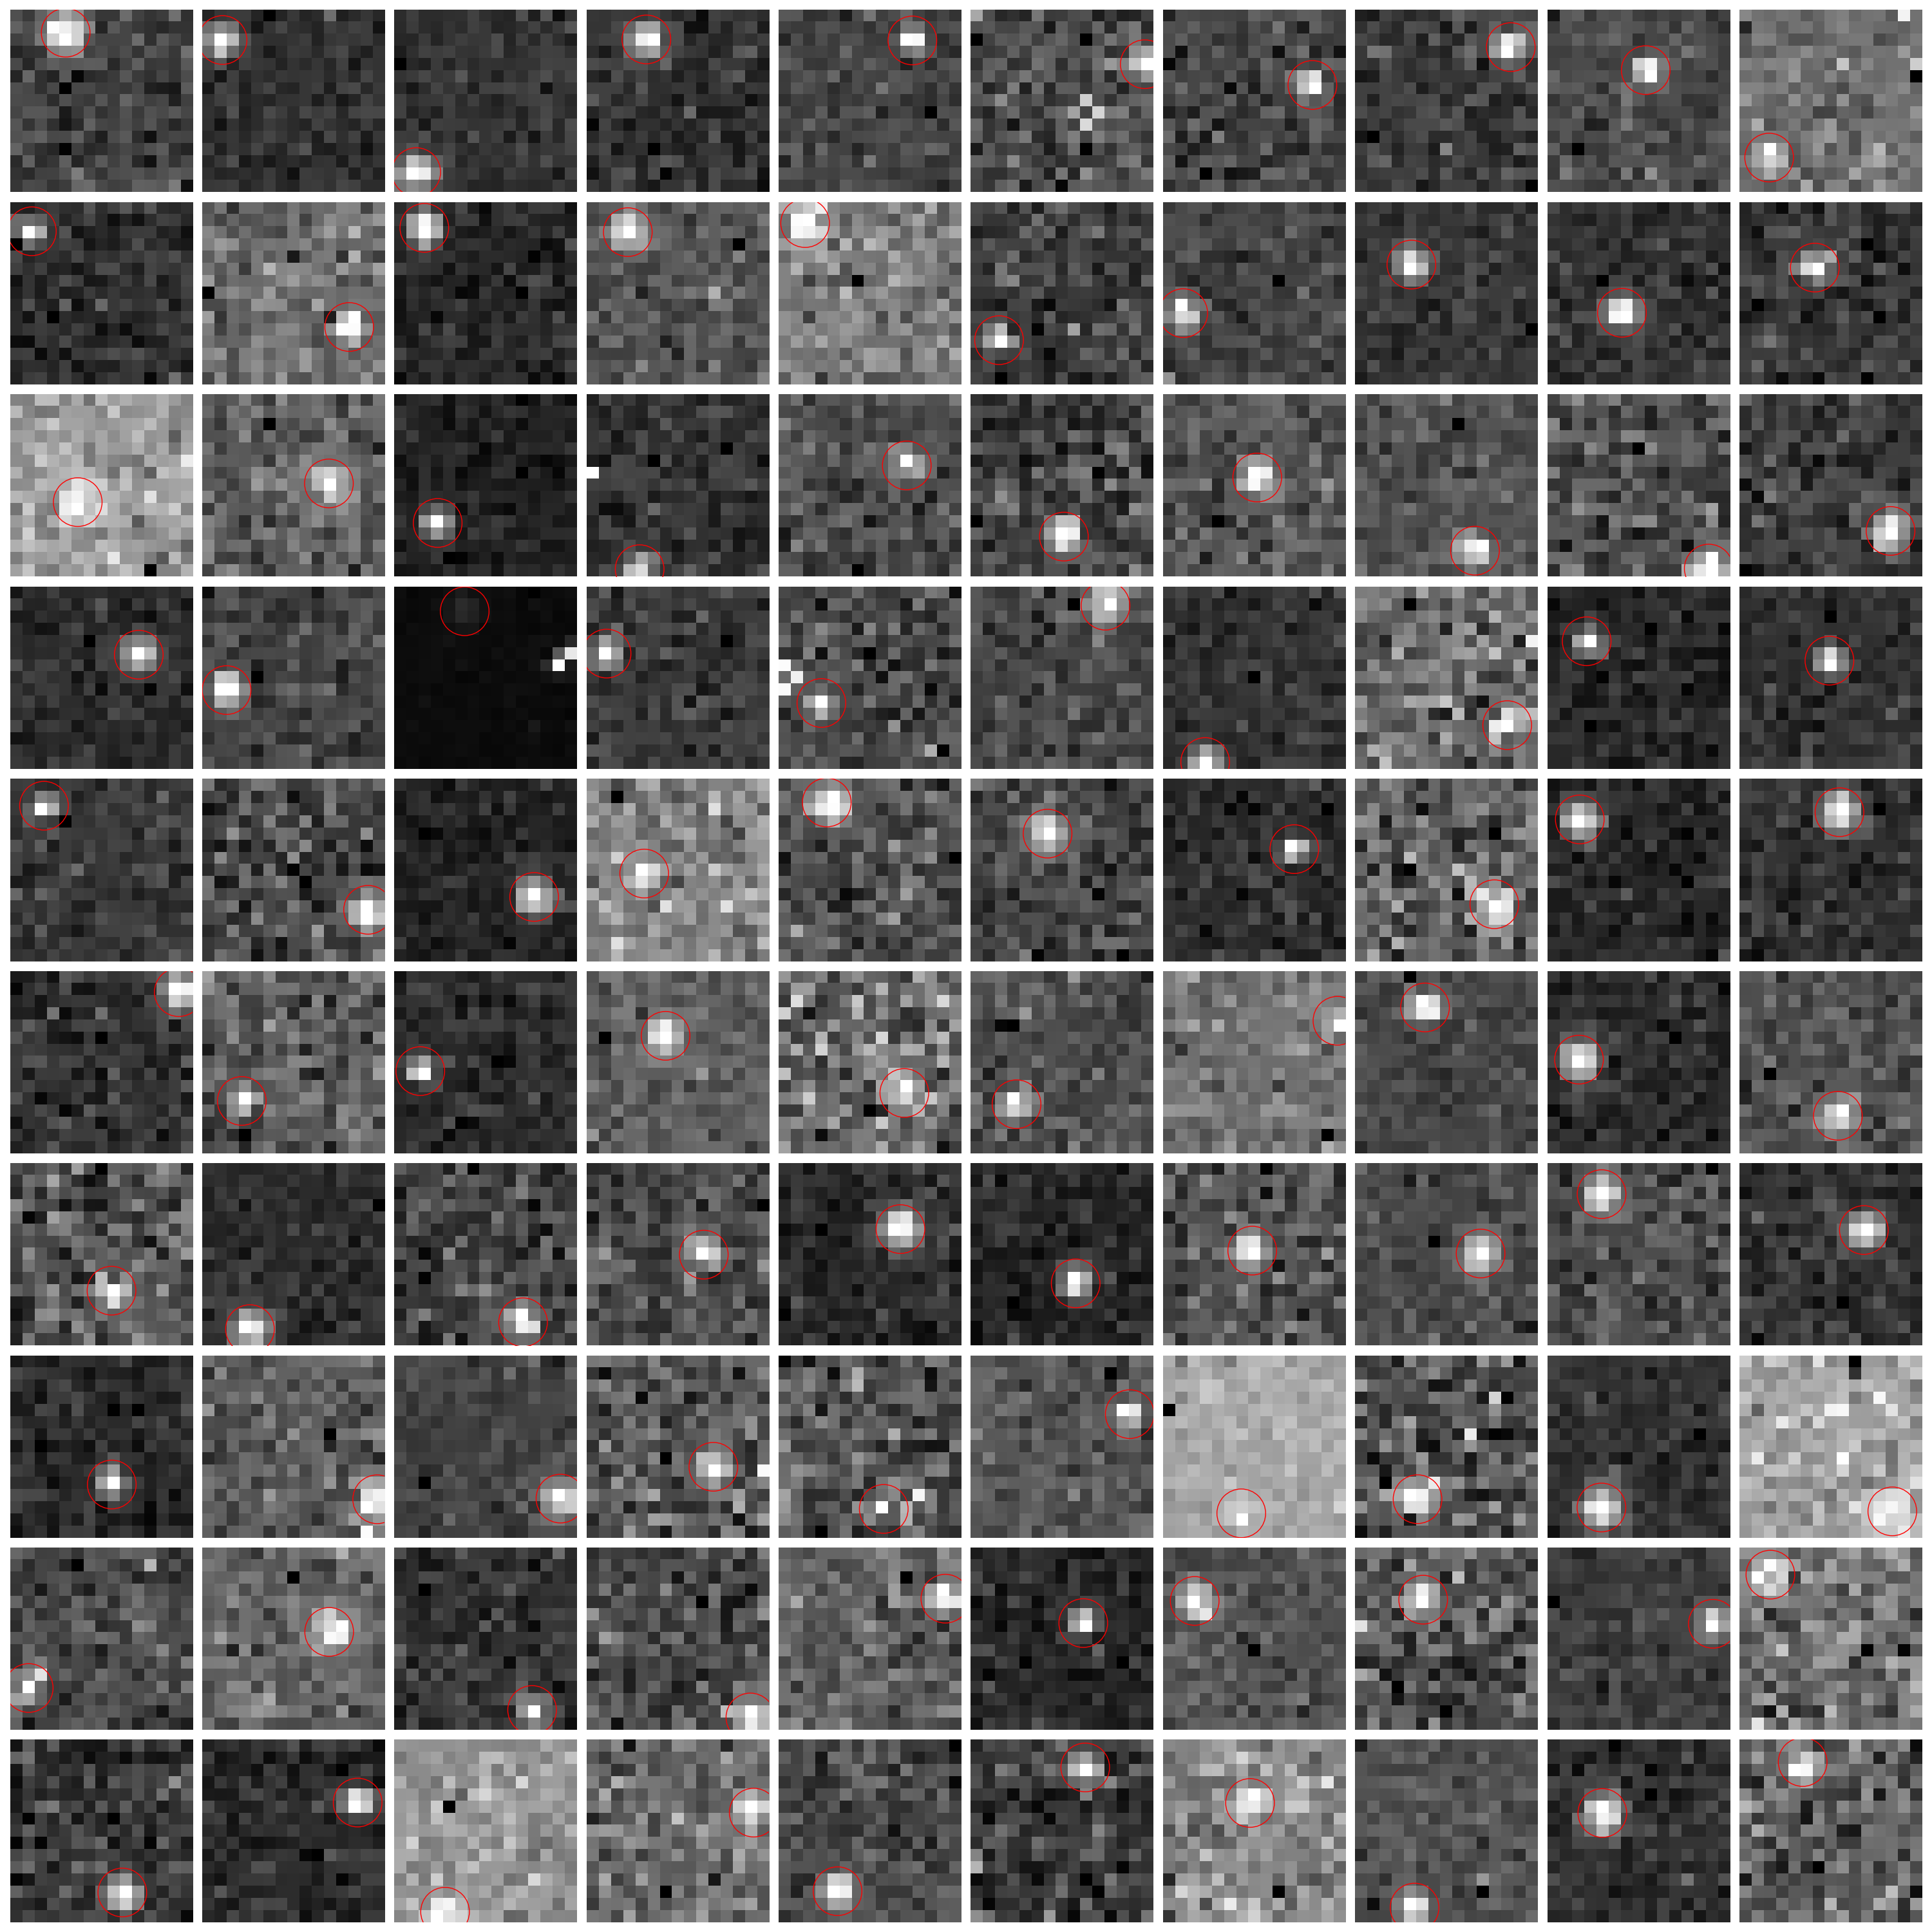

In [13]:
plot_images_with_circles(np.array(implanted_true), centers, grid_dim=(10,10))

In [530]:
# implanted_true = list(implanted_true)
# for x in range(10,12):
#     # plt.figure()
#     plot_images(implanted_true[10*x:10*x + 10],fig_height=2,norm_same=False)

In [186]:

# image_array = clean_bkgs[x]
# target_x, target_y = centers[x][0], centers[x][1]

# mask = np.zeros_like(image_array, dtype=bool)
# mask[target_y, target_x] = True
# eroded_mask = binary_dilation(mask, iterations=2)
# image_array[eroded_mask] = 0

# plot_images(image_array)

In [11]:
# clean_bkgs = np.load("./TrainingData/Oct27_DimSynthAsteroidBackgroundImages_134k_update.npy")
# implanted_true = []
# ct = 0

# for i in range(len(simImages)):

#     bkg = clean_bkgs[i]
#     target_x, target_y = int(centers[i][0]), int(centers[i][1])
#     mask = np.zeros_like(bkg, dtype=bool)
    
#     mask[target_y, target_x] = True
    
#     eroded_mask = binary_dilation(mask, iterations=2)
#     bkg[eroded_mask] = 0
    
#     add = bkg + simImages[i]
#     implanted_true.append(add)

In [ ]:
plt.close()

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

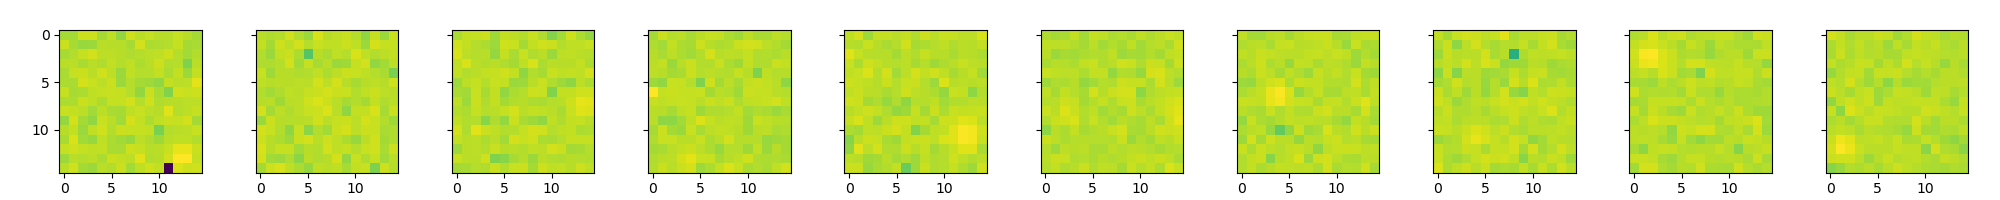

In [153]:
plot_images(implanted_true[20:30],fig_height=2)

In [208]:
# np.save("Nov3_50k_SynthTrue_ErodeImplant_oct27UpdateBkg_Amp11to30", implanted_true[0:50000])

# Filter synthetic images for specific SNR 

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
from matplotlib.patches import Circle

def calculate_snr(image_data, position, aperture_radius, annulus_radii, gain=1.0, read_noise=2.5):
    aperture = CircularAperture(position, r=aperture_radius)
    annulus = CircularAnnulus(position, r_in=annulus_radii[0], r_out=annulus_radii[1])

    aperture_phot = aperture_photometry(image_data, aperture)
    signal = aperture_phot['aperture_sum'][0]

    annulus_phot = aperture_photometry(image_data, annulus)
    bkg_mean = annulus_phot['aperture_sum'][0] / annulus.area
    bkg_total = bkg_mean * aperture.area

    net_signal = signal - bkg_total

    photon_noise = np.sqrt(np.max(net_signal * gain, 0))
    background_noise = np.sqrt(abs(bkg_total * gain)) 
    total_noise = np.sqrt(photon_noise**2 + background_noise**2 + (read_noise**2 * aperture.area))
    snr = net_signal / total_noise if total_noise != 0 else 0
    return snr, aperture


from photutils.aperture import CircularAnnulus
import numpy as np

def calculate_snr_normalized(image_data, position, aperture_radius, annulus_radii, sigma=0.2):
    aperture = CircularAperture(position, r=aperture_radius)
    annulus = CircularAnnulus(position, r_in=annulus_radii[0], r_out=annulus_radii[1])
    aperture_phot = aperture_photometry(image_data, aperture)
    signal = aperture_phot['aperture_sum'][0]
    
    annulus_phot = aperture_photometry(image_data, annulus)
    bkg_mean = annulus_phot['aperture_sum'][0] / annulus.area
    bkg_total = bkg_mean * aperture.area
    net_signal = signal - bkg_total
    
    N_pixels = aperture.area
    total_noise = sigma * np.sqrt(N_pixels)
    
    snr = net_signal / total_noise if total_noise != 0 else 0
    
    return snr, aperture


In [28]:
centers[i]

[8.757781938163006, 4.5757355757299525]

In [109]:
# im

In [ ]:
# what is min amplitude to get min SNR
# after generating must calculate SNR
# 2.5 minimum

# CALCULATE SNRs

In [29]:
SNRs = []
for i, im in enumerate(tqdm(implanted_true)):
    
    # snr, aperture = calculate_snr(im, position=(centers[i][0], centers[i][1]), aperture_radius=1.5, annulus_radii=[3, 4], gain=1.0, read_noise=2.5)
    snr, aperture = calculate_snr_normalized(im, position=(centers[i][0], centers[i][1]), aperture_radius=1.5, annulus_radii=[3, 4])

    SNRs.append(snr)

  0%|          | 0/452732 [00:00<?, ?it/s]

In [59]:
s = [v for v in SNRs if (v < 10) and (v > 0)]

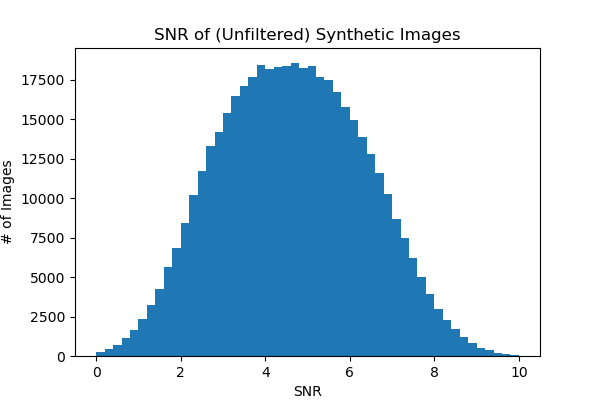

In [60]:
plt.figure(figsize=(6,4))
plt.hist(s, bins=50)
plt.xlabel("SNR")
plt.title("SNR of (Unfiltered) Synthetic Images")
plt.ylabel("# of Images")
plt.show()

# 4. Calculate SNR of the synthetic images

In [542]:
plt.close()

In [550]:
len(clean_bkgs)

452732

In [551]:
lowSNR = 3
highSNR = 20

SNRs = np.array(SNRs)

mask = (SNRs >= lowSNR) & (SNRs <= highSNR)
inds = np.where(mask)[0]
fil = np.array(implanted_true)[mask]

fil_centers = [centers[i] for i in inds]
fil_params = [gauss_params[i] for i in inds]
fil_SNRs = [SNRs[i] for i in inds]
len(fil_SNRs)

447748

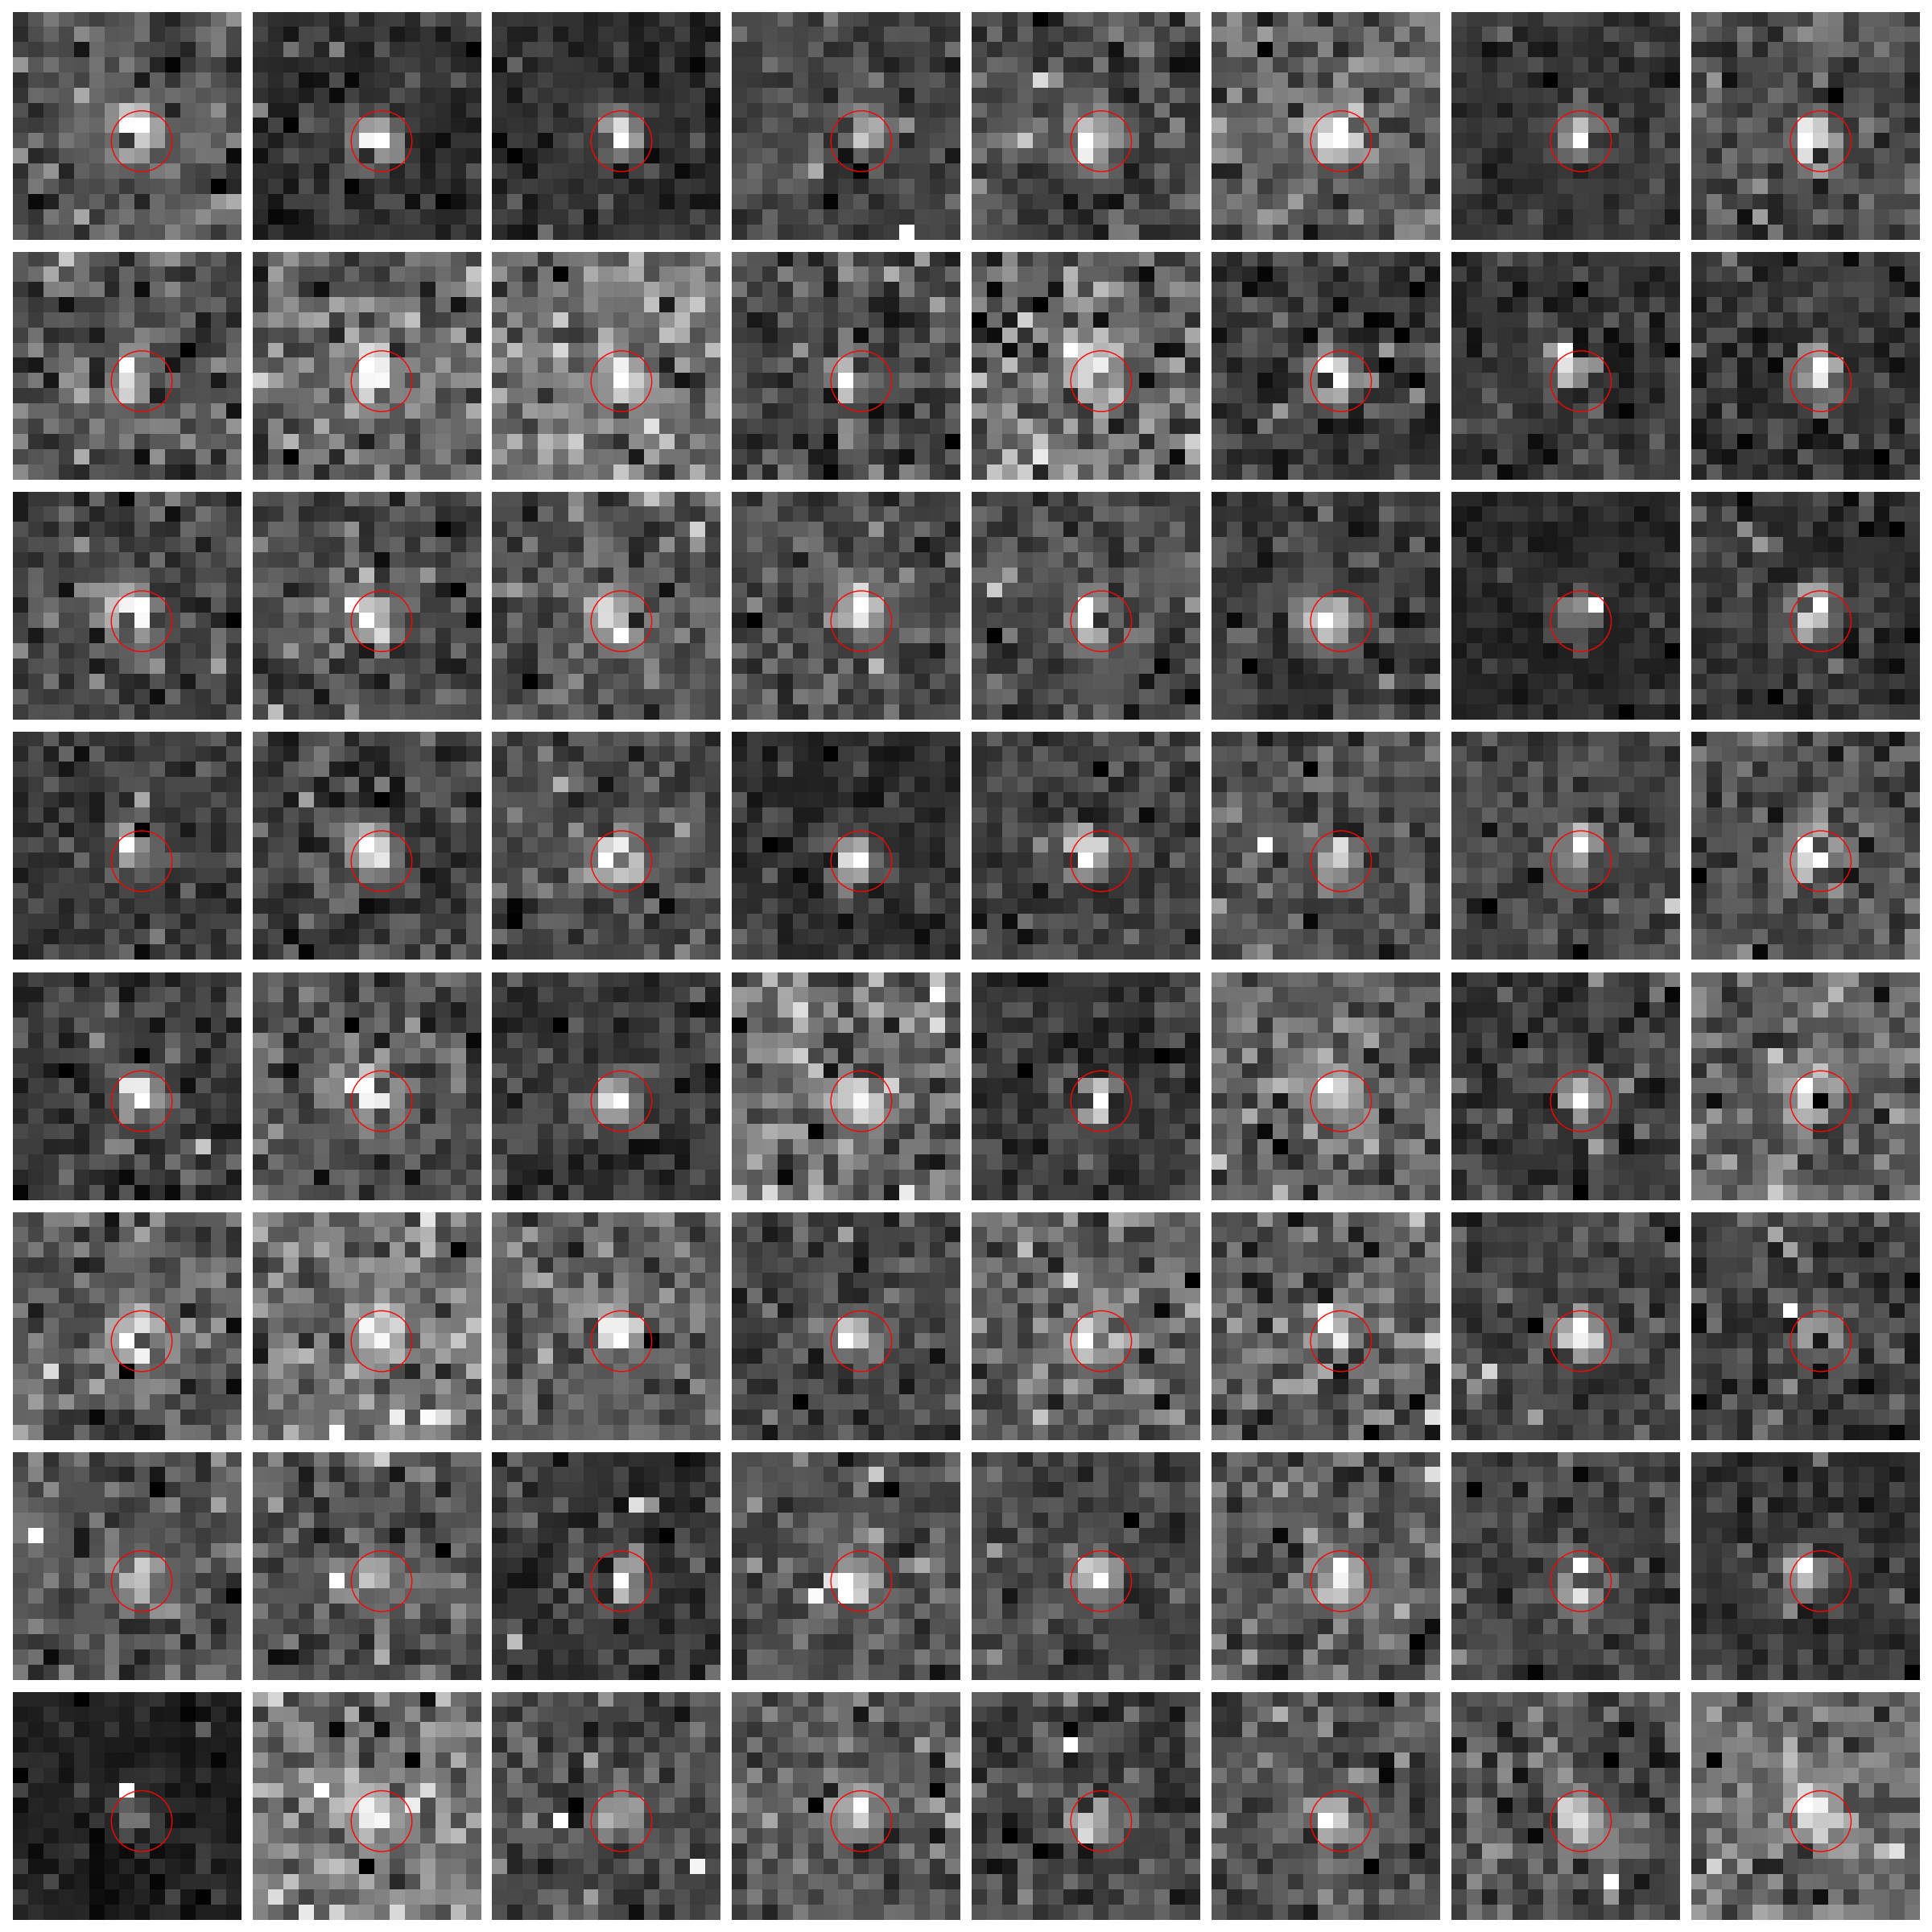

In [495]:
reals_centers = [[8,8] for i in range(len(dims_full))]
plot_images_with_circles(np.array(dims_full), reals_centers, grid_dim=(8,8))

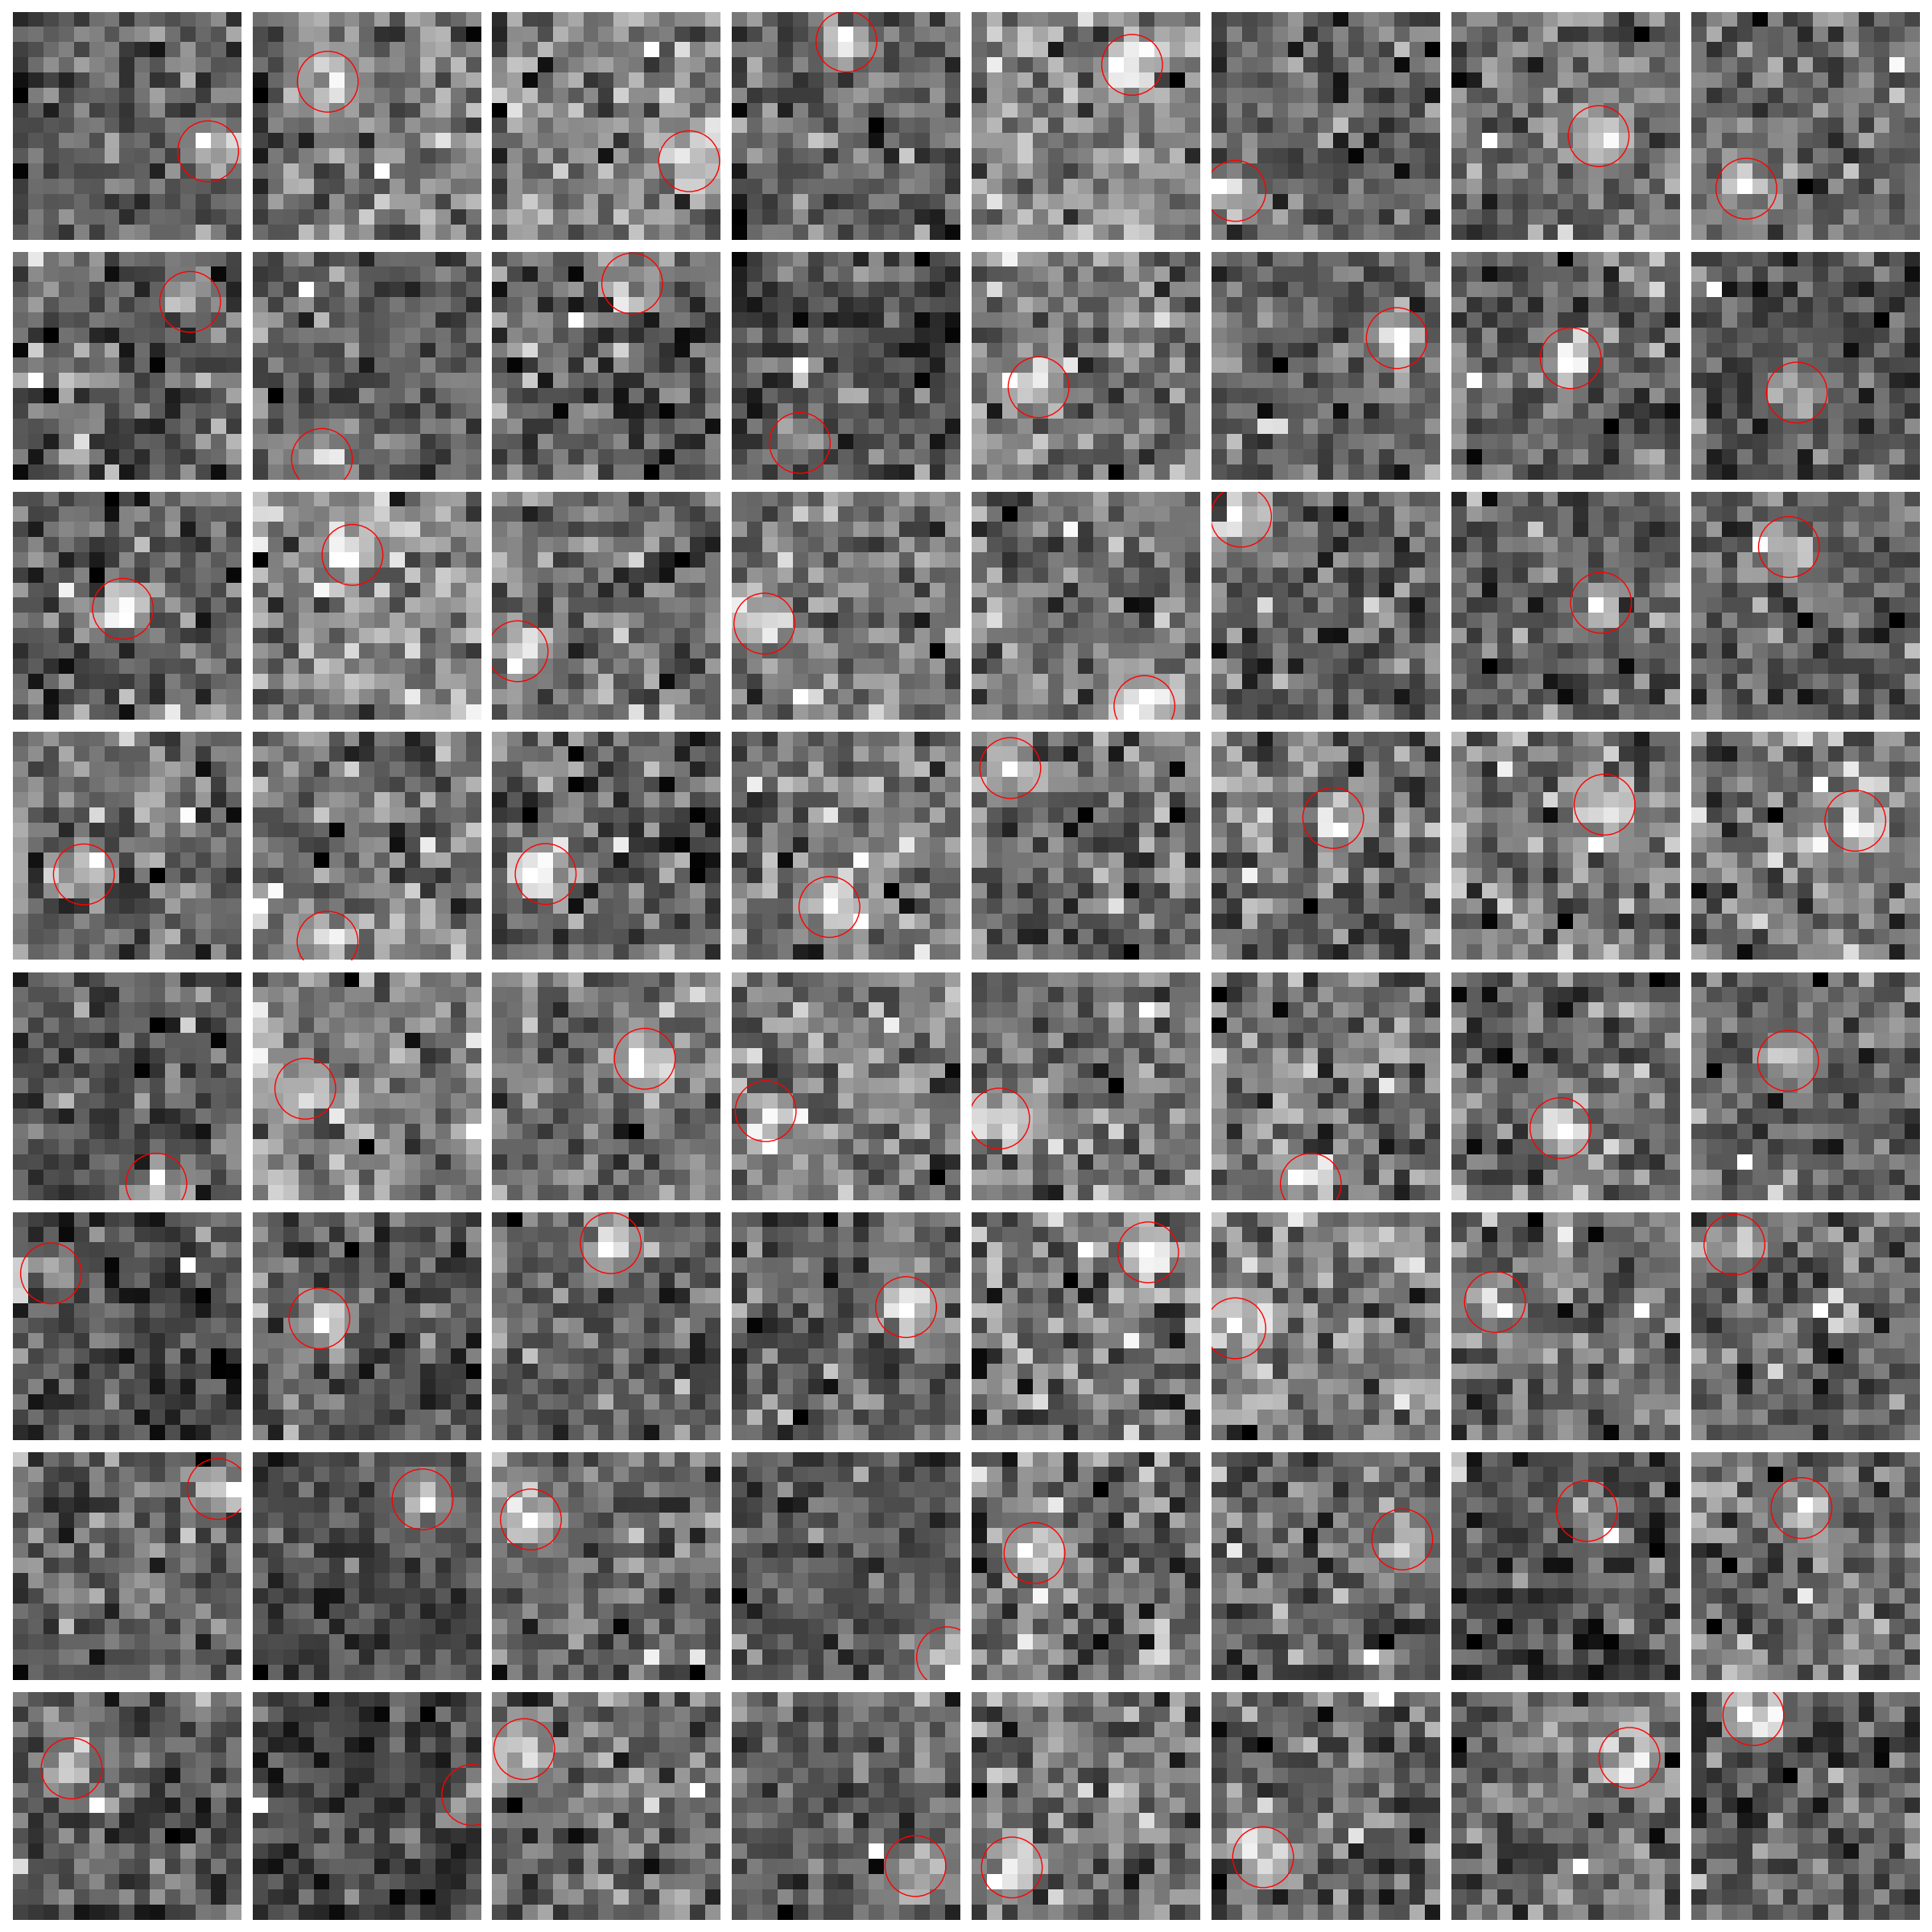

In [544]:
# plot_images_with_circles(np.array(fil[0:100]), fil_centers[0:100], grid_dim=(8,8))
plot_images_with_circles(np.array(implanted_true[0:100]), centers[0:100], grid_dim=(8,8))

In [545]:
np.save("../2025Summer/TrainingData/TrueSet/Final_True_Bkg_parts/447k_Synth_Images_June23_snr3_V1", fil)

In [546]:
np.save("../2025Summer/TrainingData/TrueSet/Final_True_Bkg_parts/447k_Centers_June23_snr3_V1", fil_centers)

In [547]:
np.save("../2025Summer/TrainingData/TrueSet/Final_True_Bkg_parts/447k_GaussParams_June23_snr3_V1", fil_params)

In [552]:
np.save("../2025Summer/TrainingData/TrueSet/Final_True_Bkg_parts/447k_SNRs_June23_snr3_V1", fil_SNRs)

In [474]:
false = np.load("../2025Summer/TrainingData/FalseSet/280k_blank_false_images.npy")
false=list(false)

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

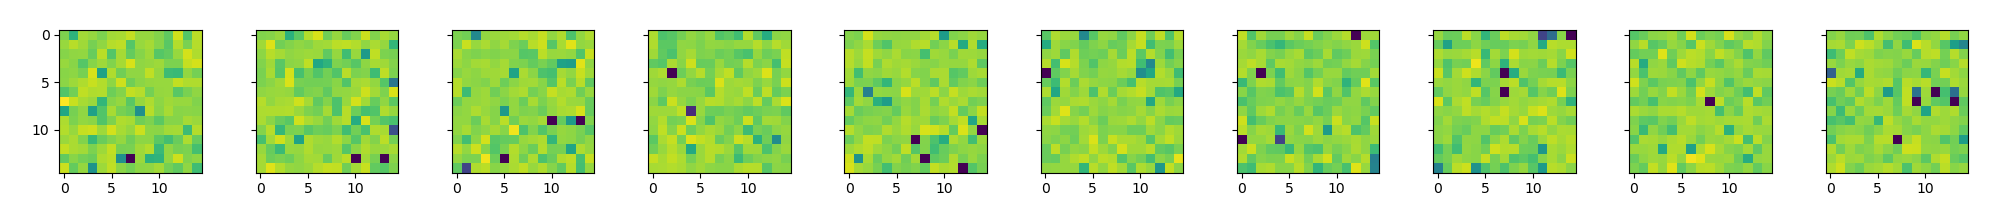

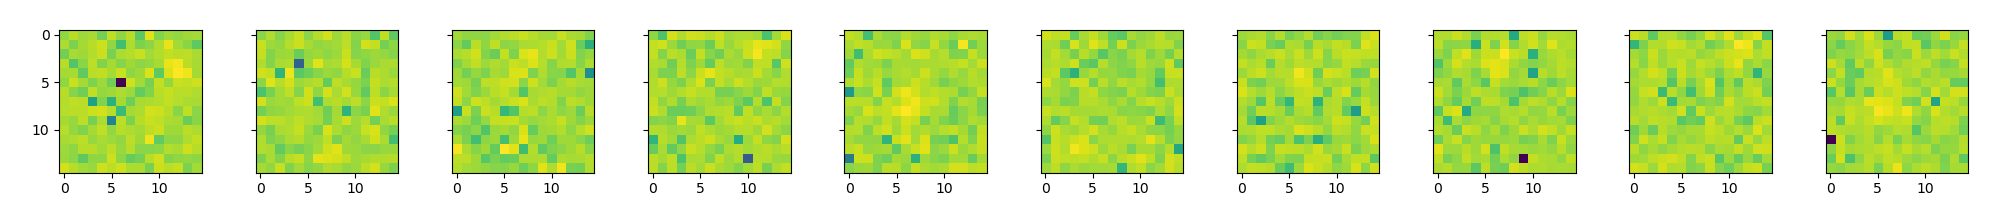

In [482]:
plot_images(false[100:110],fig_height=2)
plot_images(list(implanted_true[200:210]),fig_height=2)

In [231]:
# check small sigma params' images

small_ast = [implanted_true[i] for i in range(len(implanted_true)) if gauss_params[i][3] < 0.8]

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >], dtype=object)

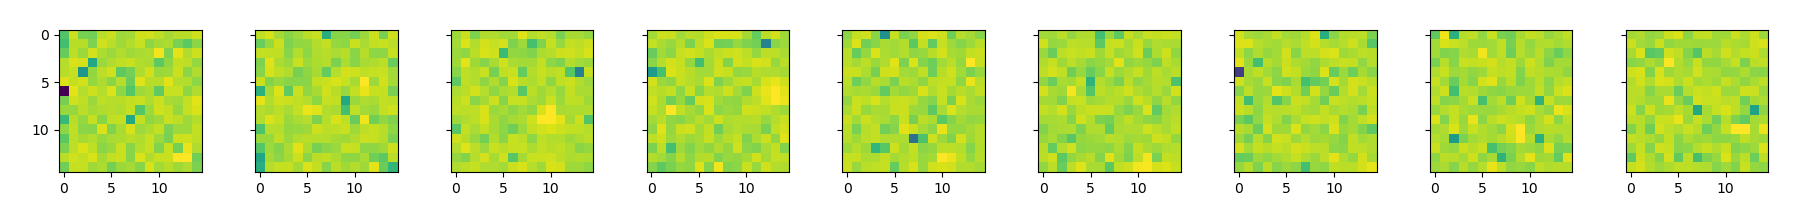

In [272]:
x = 1

plot_images(small_ast[x:10], fig_height=2)
# print(gauss_params[x])

In [202]:
np.save("../2025Summer/TrainingData/TrueSet/Final_True_Bkg_parts/v1_centers_snr2pt8", implanted_true)
np.save("../2025Summer/TrainingData/TrueSet/Final_True_Bkg_parts/v1_centers", centers)

In [7]:
# synth = np.load("./TrainingData/Apr5_true_synthetic_94k_SNRpt28_topt8_V1_ims.npy")
# plot_images(list(implanted_true[0:50]), n_rows=5, fig_height=2, norm_same=False)

In [57]:
# highpix= []
# hisnrs = []
# for i, im in enumerate(fil):
#     snr, aperture = calculate_snr(im, position=(fil_centers[i][0], fil_centers[i][1]), aperture_radius=0.5, annulus_radii=[4, 5], gain=1.0, read_noise=2.5)
#     if (snr > 1.5) and (snr < 1.6):
#         highpix.append(im)

#     hisnrs.append(snr)

In [58]:
# plot_images(highpix[0:10],fig_height=2)

In [59]:
# plt.figure()
# plt.hist(hisnrs,bins=30)

In [47]:
plt.close()

In [49]:
# plt.figure()
# x = 501
# plt.imshow(list(fil[x]), cmap='gray', origin='lower')

# aperture_circle = Circle((centers[x][0], centers[x][1]), 1.5, color='red', fill=False, lw=2)

# plt.gca().add_patch(aperture_circle)

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >], dtype=object)

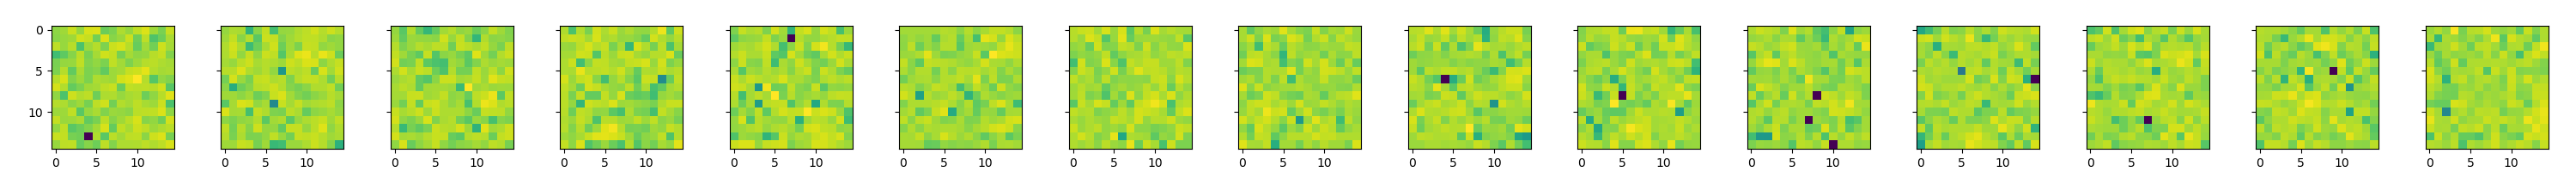

In [51]:
plot_images(list(fil[0:15]),fig_height=2)

In [265]:
np.save("./TrainingData/36k_TrueImages_updatebkgs_SNR5_to_8_oct27", fil)

In [37]:
plt.close()

# Filtering synthetic images based on SNR

In [27]:
plt.close()

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

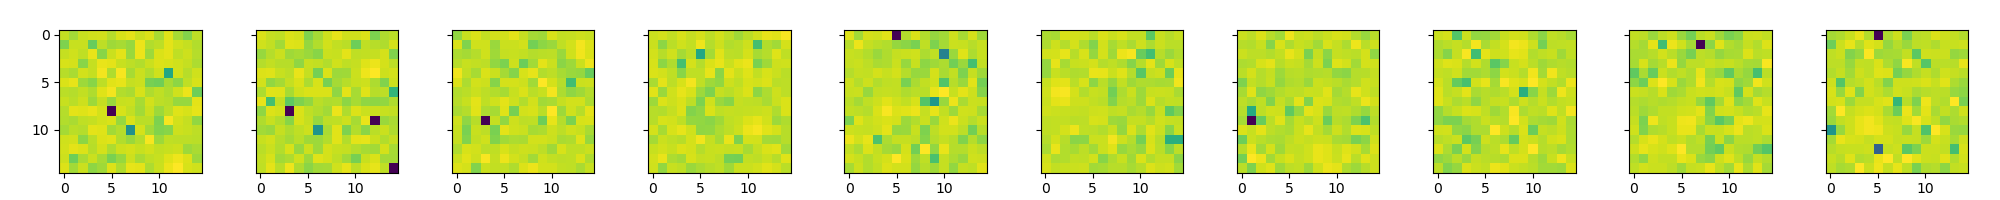

In [47]:
plot_images(fil[20:30], fig_height=2)

# Download backround images  + bitmasks

In [51]:
import numpy as np

def find_patterns(image):
    target_value = 268435456

    height, width = image.shape
    mask_image = np.zeros((height, width), dtype=int)

    for y in range(height - 1):
        for x in range(width - 1):
            if (image[y, x] == target_value and
                image[y, x + 1] == target_value and
                image[y + 1, x] == target_value and
                image[y + 1, x + 1] == target_value):
                
                mask_image[y, x] = 1
                mask_image[y, x + 1] = 1
                mask_image[y + 1, x] = 1
                mask_image[y + 1, x + 1] = 1

            if (image[y, x] == target_value and
                image[y + 1, x + 1] == target_value):
                mask_image[y, x] = 1
                mask_image[y + 1, x + 1] = 1

            if (image[y, x + 1] == target_value and
                image[y + 1, x] == target_value):
                mask_image[y, x + 1] = 1
                mask_image[y + 1, x] = 1

            if image[y, x] == target_value and image[y + 1, x] == target_value:
                mask_image[y, x] = 1
                mask_image[y + 1, x] = 1

            if image[y, x] == target_value and image[y, x + 1] == target_value:
                mask_image[y, x] = 1
                mask_image[y, x + 1] = 1

    for y in range(height - 1):
        if image[y, width - 1] == target_value and image[y + 1, width - 1] == target_value:
            mask_image[y, width - 1] = 1
            mask_image[y + 1, width - 1] = 1

    for x in range(width - 1):
        if image[height - 1, x] == target_value and image[height - 1, x + 1] == target_value:
            mask_image[height - 1, x] = 1
            mask_image[height - 1, x + 1] = 1

    return mask_image

def remove_artifacts(mask, img):
    
    original_img = np.copy(img)
    
    bm = find_patterns(mask)
    c_obj_map = binary_dilation(bm, iterations=4)
    
    img[c_obj_map] = np.nan
    non_nan_pixels = img[~np.isnan(img)]
    background_noise = np.std(non_nan_pixels)
    
    nan_mask = np.isnan(img)
    
    img[nan_mask] = np.random.normal(0, background_noise, size=nan_mask.sum())
    
    # plot_images([mask, original_img, c_obj_map, img], fig_height=2, norm_same=False)
    if (original_img==img).all():
        corrected = False;
    else:
        corrected= True
    return img, corrected


## Download bkgs and bitmasks

In [ ]:
bitmasks = np.load("../Search_6/SearchedData/F19_Bitmasks.npy")
ims = np.load("../Search_6/SearchedData/F19_DeployGridFrames.npy")

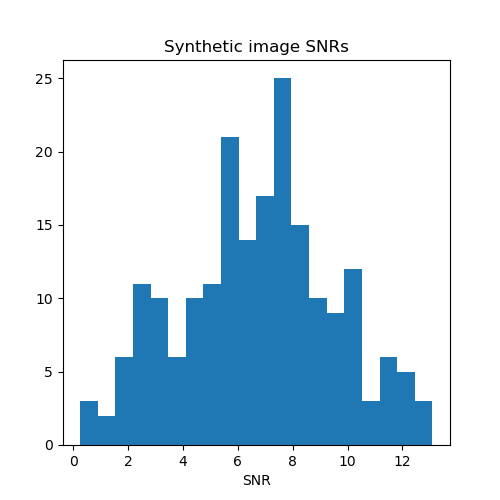

In [623]:
plt.figure(figsize=(5,5))
plt.hist(SNRs,bins=20)
plt.xlabel("SNR")
plt.title("Synthetic image SNRs")
plt.show()
# plt.close()

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

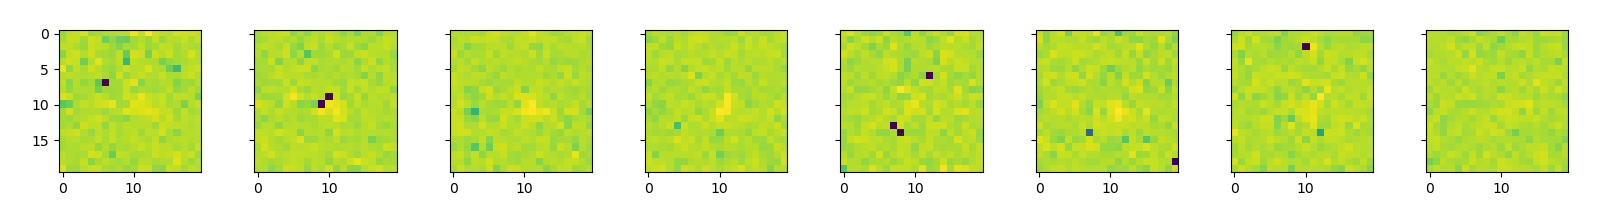

In [234]:
dim_w2_ims = list(dim_w2_ims)
plot_images(dim_w2_ims[30:38],fig_height=2)

# Comparing real vs synthetic SNR plots

In [2]:
synth = np.load("./TrainingData/100k_TrueImages_First100kof100CleanedFrames_SNR4to9.npy")

np.save("./TrainingData/Oct27_DimSynthAsteroidBackgroundImages_134k", grids)

In [6]:
synth = list(synth)

In [118]:
len(fil)

30795

In [144]:
fil = fil[0:100000]

In [ ]:
np.save("./TrainingData/100k_Oct24RedoneSyntheticImages_BRIGHT_SNR8over", fil)

In [106]:
plt.close()

In [12]:
SNRs = []
for i, im in enumerate(implanted_true):
    
    snr, aperture = calculate_snr(im, position=(centers[i][0], centers[i][1], 7.5), aperture_radius=2, annulus_radii=[4, 5], gain=1.0, read_noise=2.5)

    SNRs.append(snr)


In [142]:
fil = [implanted_true[i] for i in range(len(SNRs)) if (SNRs[i] >= 9)] # and (gauss_params[i][4] < 1.3) and (gauss_params[i][4] > 1)] # was 3 to 7

fil_params = [gauss_params[i] for i in range(len(SNRs)) if (SNRs[i] >= 9)] # and (gauss_params[i][4] < 1.3) and (gauss_params[i][4] > 1)] # was 3 to 7

fil_snrs = [SNRs[i] for i in range(len(SNRs)) if (SNRs[i] >= 9)] # and (gauss_params[i][4] < 1.3) and (gauss_params[i][4] > 1)] # was 3 to 7

41 :   [39.21911513536902, 7.49366145110349, 10.855583250289001, 0.8203044708535191, 0.7376725825681828] SNR:  9.95645557036321
42 :   [39.80801983737157, 5.263308438288009, 1.6102042776500776, 1.2560163960534205, 1.2919686697963255] SNR:  14.331943351222009
43 :   [30.584712290399366, 12.645769587044704, 1.2532109205005848, 1.1603412611289277, 1.0636861935104531] SNR:  10.388746084027547
44 :   [35.12487603290243, 1.5918955301005886, 12.97233615050955, 1.1769657402168106, 1.1736445955355208] SNR:  12.364586058194002
45 :   [28.580409991803847, 7.6097708994638, 13.400027483543848, 1.3870865039329923, 1.3789809225903218] SNR:  11.959265977533278
46 :   [35.48910012794934, 5.139313381980295, 6.606383843624016, 1.4973728362268297, 1.5519111979639904] SNR:  15.511684385272076
47 :   [36.08367481719369, 11.436485580751418, 12.76336736757659, 0.7899492781081692, 0.8621231306642752] SNR:  9.560136971356673
48 :   [29.642533254537867, 3.171382868215575, 3.63378365217252, 1.0086527478785032, 0.

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

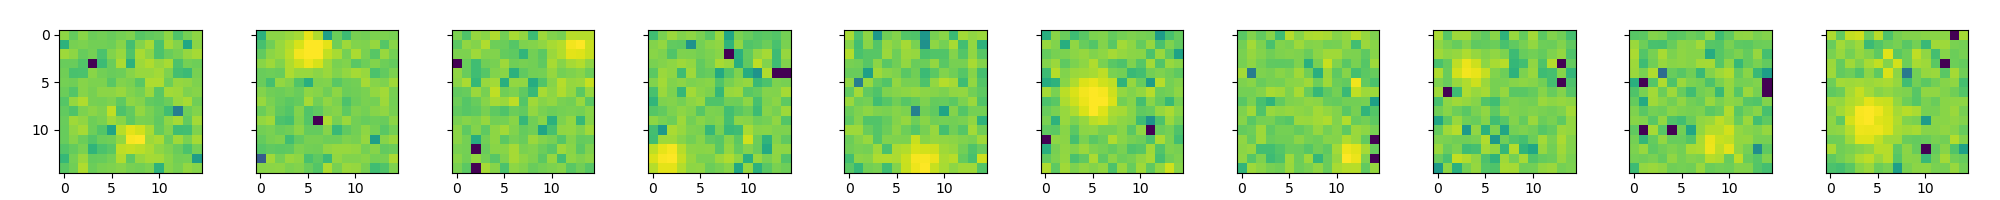

In [143]:
a = 40
b = 50

for i in range(a,b):
    print(i + 1, ":  ", fil_params[i], "SNR: ", fil_snrs[i])
plot_images(fil[a:b], fig_height=2)

In [141]:
len(fil)

144625

In [25]:
# plt.figure(figsize=(10,4))
# # plt.hist(real_SNRs, label="real SNRs")
# SNRs = np.array(SNRs)

# plt.hist(SNRs[SNRs < 20])

# plt.xlabel("SNR")
# plt.title("Synthetic SNRs Distribution")
# # plt.legend()
# plt.show()

In [21]:
real_SNRs = []
for im in dim_w2_ims:
    snr, aperture = calculate_snr(im, position=(10,10), aperture_radius=2, annulus_radii=[4,5], gain=1.0, read_noise=5)
    real_SNRs.append(snr)

In [ ]:
real_SNRs

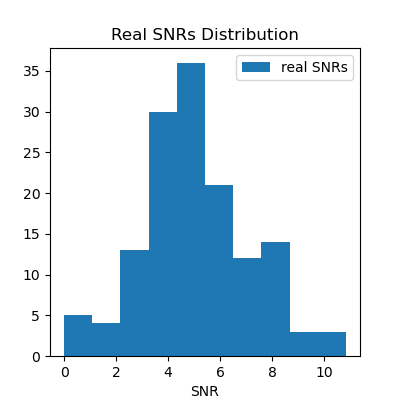

In [22]:
plt.figure(figsize=(4,4))
plt.hist(real_SNRs, label="real SNRs")

# plt.hist(SNRs, label="synthetic SNRs")


plt.xlabel("SNR")
plt.title("Real SNRs Distribution")
plt.legend()
plt.show()

In [25]:
filterSynth = [implanted_true[i] for i in range(len(SNRs)) if (SNRs[i] >= 4) and (SNRs[i] <= 4.2)]
filterReal = [dim_w2_ims[i] for i in range(len(real_SNRs)) if (real_SNRs[i] >= 4) and (real_SNRs[i] <= 4.2)]

In [55]:
plt.close()

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >], dtype=object)

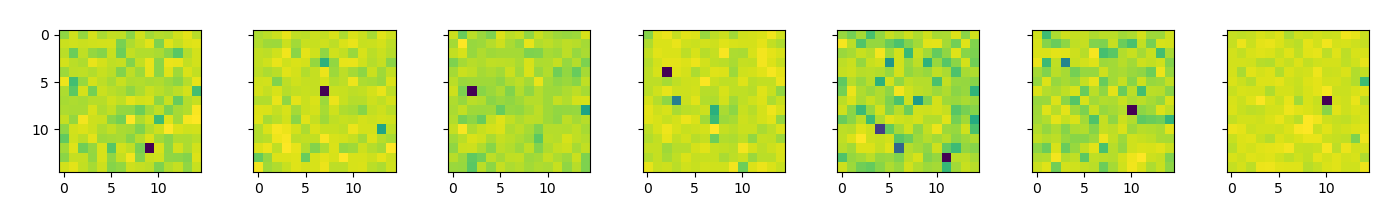

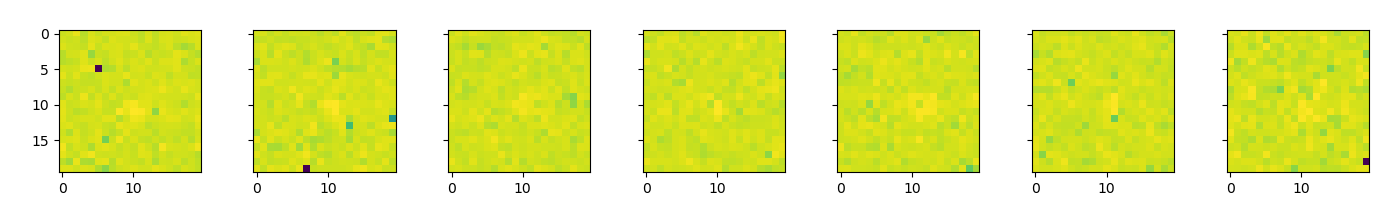

In [64]:
plot_images(filterSynth[200:207], fig_height=2, norm_same= False)
plot_images(filterReal[0:], fig_height=2)

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >], dtype=object)

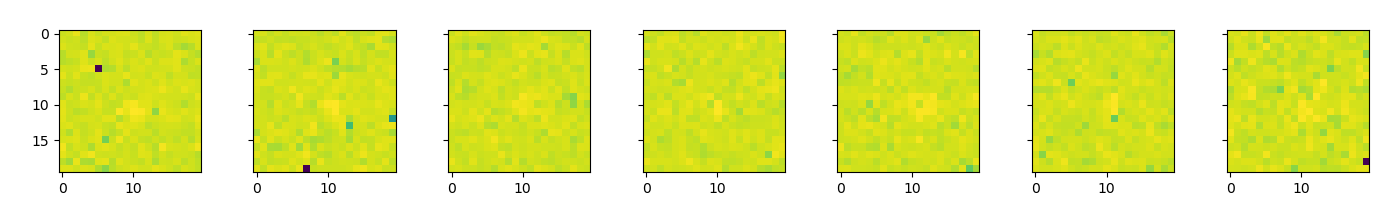

In [35]:
plot_images(filterReal[0:9], fig_height=2)